In [1]:
import numpy as np
from matplotlib import pyplot as plt
import gillespy2

In [31]:
def opto_input(t):
    out = 50 if t<100 else 0
    return str(out)

def CcaSR_1layer(init_con, params,fun, t_max,parameter_values=None):    

    model = gillespy2.Model(name='CcaSR')
    
    alpha , k , n , tau_delay , h1 , h2 , c2,delta = params
    

    alpha_g = gillespy2.Parameter(name='alpha', expression=alpha)
    delta_g = gillespy2.Parameter(name='delta', expression=delta)
    c2_g = gillespy2.Parameter(name='c2', expression=c2)
    k_g = gillespy2.Parameter(name='k', expression=k)
    n_g = gillespy2.Parameter(name='n', expression=n)
    tau_delay_g = gillespy2.Parameter(name='tau_delay', expression=tau_delay)
    h1_g = gillespy2.Parameter(name='h1', expression=h1)
    h2_g = gillespy2.Parameter(name='h2', expression=h2)
    
    model.add_parameter([alpha_g,delta_g,c2_g,k_g,n_g,tau_delay_g,h1_g,h2_g])

    
    U = gillespy2.Species(name='U', initial_value=1,mode='discrete')
    H = gillespy2.Species(name='H', initial_value=init_con[0])
    E = gillespy2.Species(name='E',   initial_value=round(np.random.poisson(h1/h2)))
    F = gillespy2.Species(name='F',   initial_value=init_con[2])
    model.add_species([U,H,E,F])

    # The list of reactants and products for a Reaction object are each a
    # Python dictionary in which the dictionary keys are Species objects
    # and the values are stoichiometries of the species in the reaction.
    H_c = gillespy2.Reaction(name="H_creation", propensity_function= 'U', reactants={}, products={H:1})
    H_d = gillespy2.Reaction(name="H_dissociation", propensity_function='c2*H', reactants={H:1}, products={})
    E_c = gillespy2.Reaction(name="E_creation", propensity_function= 'h1', reactants={}, products={E:1})
    E_d = gillespy2.Reaction(name="E_dissociation", propensity_function='h2*E', reactants={E:1}, products={})
    F_c = gillespy2.Reaction(name="F_creation", propensity_function= 'alpha*E*(pow(c2*H,n)/(k+pow(c2*H,n)))', reactants={}, products={F:1})
    F_d = gillespy2.Reaction(name="F_dissociation", propensity_function='delta*F', reactants={F:1}, products={})
    
    model.add_reaction([H_c,H_d,E_c,E_d,F_c,F_d])

    # Set the timespan for the simulation.
    tspan = gillespy2.TimeSpan.linspace(t=t_max, num_points=101)
    model.timespan(tspan)
    return model


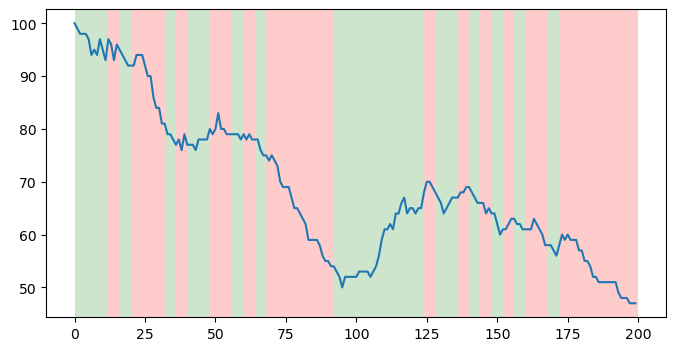

In [101]:
class Simple(gillespy2.Model):
    def __init__(self,params,t_max,stim_vec):
        super().__init__(name='Simple_rxn')
        self.params = params
        self.t_max = t_max
        self.stim_vec = stim_vec
    
    
    def init_rxn(self):
        delta = self.params

        delta_g = gillespy2.Parameter(name='delta', expression=delta)
        
        self.add_parameter([delta_g])

        
        A = gillespy2.Species(name='A', initial_value=100,mode='discrete')
        B = gillespy2.Species(name='B', initial_value=0,mode='discrete')
        self.add_species([A,B])

        # The list of reactants and products for a Reaction object are each a
        # Python dictionary in which the dictionary keys are Species objects
        # and the values are stoichiometries of the species in the reaction.
        A_d = gillespy2.Reaction(name="A_degradation", propensity_function= 'delta*A', reactants={A:1}, products={})
        A_c = gillespy2.Reaction(name="A_creation", propensity_function= 'B', reactants={}, products={A:1})
        self.add_reaction([A_d,A_c])
    
    def update_rxn(self,updates):
        Species = self.get_all_species().keys()
        for i in Species:
            ea = gillespy2.EventAssignment(variable=i, expression=updates[i])
            et = gillespy2.EventTrigger(expression='1',initial_value=False)
            e = gillespy2.Event(name=f'event{i}', trigger=et, assignments=[ea])
            self.add_event([e])
        

    def run_rxn(self):
        tspan = gillespy2.TimeSpan.linspace(t=self.t_max, num_points=int(self.t_max))
        self.timespan(tspan)
        results = self.run(number_of_trajectories=1,algorithm="Tau-Hybrid")
        self.delete_all_events()
        return results

    def full_run(self,report_species,input_species):
        res = []
        self.init_rxn()
        for i in range(len(self.stim_vec)):
            results = self.run_rxn()
            res.append(results[report_species][1:])
            updates = {}
            for k in self.get_all_species().keys():
                updates[k] = results[k][-1]
            updates[input_species] = self.stim_vec[i]
            self.update_rxn(updates)
        return res
stim_vec = np.random.choice(2,50)
test = Simple(0.01,5,stim_vec)
res = test.full_run('A','B')

fig, ax = plt.subplots(figsize=(8, 4))
for i, val in enumerate(stim_vec):
    x_start = i * 4
    x_end = x_start + 4
    color = 'green' if val == 1 else 'red'
    ax.axvspan(x_start, x_end, facecolor=color, alpha=0.2)

ax.plot(np.concatenate(res))
plt.show()        


In [ ]:
class CcaSR(gillespy2.Model):
    def __init__(self,params,t_max,stim_vec):
        super.__init__(name='CcaSR')
        self.params = params
        self.t_max = t_max
        self.stim_vec = stim_vec
    
    def init_rxn(self):
        alpha , k , n , tau_delay , h1 , h2 , c2,delta = self.params

        alpha_g = gillespy2.Parameter(name='alpha', expression=alpha)
        delta_g = gillespy2.Parameter(name='delta', expression=delta)
        c2_g = gillespy2.Parameter(name='c2', expression=c2)
        k_g = gillespy2.Parameter(name='k', expression=k)
        n_g = gillespy2.Parameter(name='n', expression=n)
        tau_delay_g = gillespy2.Parameter(name='tau_delay', expression=tau_delay)
        h1_g = gillespy2.Parameter(name='h1', expression=h1)
        h2_g = gillespy2.Parameter(name='h2', expression=h2)
        
        self.add_parameter([alpha_g,delta_g,c2_g,k_g,n_g,tau_delay_g,h1_g,h2_g])

        
        U = gillespy2.Species(name='U', initial_value=0,mode='discrete')
        H = gillespy2.Species(name='H', initial_value=0)
        E = gillespy2.Species(name='E',   initial_value=round(np.random.poisson(h1/h2)))
        F = gillespy2.Species(name='F',   initial_value=0)
        self.add_species([U,H,E,F])

        # The list of reactants and products for a Reaction object are each a
        # Python dictionary in which the dictionary keys are Species objects
        # and the values are stoichiometries of the species in the reaction.
        H_c = gillespy2.Reaction(name="H_creation", propensity_function= 'U', reactants={}, products={H:1})
        H_d = gillespy2.Reaction(name="H_dissociation", propensity_function='c2*H', reactants={H:1}, products={})
        E_c = gillespy2.Reaction(name="E_creation", propensity_function= 'h1', reactants={}, products={E:1})
        E_d = gillespy2.Reaction(name="E_dissociation", propensity_function='h2*E', reactants={E:1}, products={})
        F_c = gillespy2.Reaction(name="F_creation", propensity_function= 'alpha*E*(pow(c2*H,n)/(k+pow(c2*H,n)))', reactants={}, products={F:1})
        F_d = gillespy2.Reaction(name="F_dissociation", propensity_function='delta*F', reactants={F:1}, products={})
    
        self.add_reaction([H_c,H_d,E_c,E_d,F_c,F_d])
    
    
    